# TRELLIS.2 — RunPod GPU Setup & Inference

Tested on **A100 / H100 (24 GB+ VRAM)** with CUDA 12.4.  
Run cells top-to-bottom on a fresh RunPod PyTorch pod.

## 1. Verify GPU

In [1]:
!nvidia-smi

Thu Apr  9 12:19:14 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 570.195.03             Driver Version: 570.195.03     CUDA Version: 12.8     |
|-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A40                     On  |   00000000:4F:00.0 Off |                    0 |
|  0%   33C    P8             35W /  300W |       0MiB /  46068MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [2]:
!nvcc --version

nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2024 NVIDIA Corporation
Built on Thu_Mar_28_02:18:24_PDT_2024
Cuda compilation tools, release 12.4, V12.4.131
Build cuda_12.4.r12.4/compiler.34097967_0


## 2. Clone Repo (skip if already present)

In [3]:
import os

REPO_DIR = "/workspace/TRELLIS.2"

if not os.path.isdir(REPO_DIR):
    !git clone https://github.com/RahulBhalleySP/TRELLIS.2.git {REPO_DIR}
else:
    print(f"Repo already present at {REPO_DIR}")

os.chdir(REPO_DIR)
print("Working directory:", os.getcwd())

# Persist repo path so bash cells can find it without hardcoding
with open('/tmp/trellis2_repo', 'w') as f:
    f.write(REPO_DIR)

Cloning into '/workspace/TRELLIS.2'...
remote: Enumerating objects: 411, done.
remote: Counting objects: 100% (247/247), done.
remote: Compressing objects: 100% (175/175), done.
remote: Total 411 (delta 90), reused 91 (delta 72), pack-reused 164 (from 1)
Receiving objects: 100% (411/411), 17.33 MiB | 5.93 MiB/s, done.
Resolving deltas: 100% (98/98), done.
Updating files: 100% (272/272), done.
Working directory: /workspace/TRELLIS.2


## 3. Install Dependencies

All packages — PyTorch, Python libraries, CUDA extensions — are built/downloaded once and cached to `/workspace/wheels/`.  
On subsequent runs the cell just restores from cache and exits in seconds.

### 3a. PyTorch (CUDA 12.4)

In [4]:
!pip install torch==2.6.0 torchvision==0.21.0 --index-url https://download.pytorch.org/whl/cu124 -q

ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
torchaudio 2.4.1+cu124 requires torch==2.4.1, but you have torch 2.6.0+cu124 which is incompatible.


### 3b. Basic Python packages

In [5]:
!pip install "typing_extensions>=4.10.0" -q
!pip install imageio imageio-ffmpeg tqdm easydict opencv-python-headless ninja \
             trimesh transformers gradio==6.0.1 tensorboard pandas lpips zstandard \
             kornia timm usd-core -q
!pip install git+https://github.com/EasternJournalist/utils3d.git@9a4eb15e4021b67b12c460c7057d642626897ec8 -q

# pillow-simd is a drop-in faster Pillow; fall back to stock Pillow if build fails
!apt-get update -qq && apt-get install -y libjpeg-turbo8-dev zlib1g-dev -qq 2>/dev/null || \
 apt-get install -y libjpeg-dev zlib1g-dev -qq 2>/dev/null || true
!pip install pillow-simd -q 2>/dev/null || pip install Pillow -q
!python -c "from PIL import Image; print('Pillow OK:', Image.__version__)"
!python -c "from pxr import Usd; print('usd-core OK:', Usd.GetVersion())"



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip

[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip
Selecting previously unselected package libjpeg-turbo8-dev:amd64.
(Reading database ... 24135 files and directories currently installed.)
Preparing to unpack .../libjpeg-turbo8-dev_2.1.2-0ubuntu1_amd64.deb ...
Unpacking libjpeg-turbo8-dev:amd64 (2.1.2-0ubuntu1) ...
Selecting previously unselected package zlib1g-dev:amd64.
Preparing to unpack .../zlib1g-dev_1%3a1.2.11.dfsg-2ubuntu9.2_amd64.deb ...
Unpacking zlib1g-dev:amd64 (1:1.2.11.dfsg-2ubuntu9.2) ...
Setting up libjpeg-turbo8-dev:amd64 (2.1.2-0ubuntu1) ...
Setting up zlib1g-dev:amd64 (1:1.2.11.dfsg-2ubuntu9.2) ...
Pillow OK: 9.5.0.post2
usd-core OK: (0, 26, 3)


In [6]:
# ── Configuration ─────────────────────────────────────────────────────────────
# Set False to skip flash-attn (falls back to PyTorch SDPA — slower but always works)
USE_FLASH_ATTN = True


### 3c. Flash-Attention

In [7]:
if USE_FLASH_ATTN:
    import subprocess, os
    env = {**os.environ, "MAX_JOBS": str(os.cpu_count())}
    subprocess.run(
        ["pip", "install", "flash-attn==2.7.3", "--no-build-isolation", "-q"],
        env=env, check=True
    )
    print("flash-attn installed")
else:
    print("flash-attn skipped — using PyTorch SDPA fallback")


flash-attn installed



[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python -m pip install --upgrade pip


### 3d. CUDA extensions (nvdiffrast, nvdiffrec, CuMesh, FlexGEMM, O-Voxel)

Wheels are compiled once and cached to `/workspace/wheels/`.  
On subsequent runs the cached `.whl` files are installed directly — no recompilation.

In [8]:
%%bash
export PIP_DISABLE_PIP_VERSION_CHECK=1
export PIP_ROOT_USER_ACTION=ignore
set -eo pipefail

WHEEL_DIR="/workspace/wheels"
WHEEL_ZIP="/workspace/wheels.zip"
EXT_DIR="/tmp/extensions"

# ── Restore cache from zip if folder not yet present ─────────────────────────
if [ ! -d "$WHEEL_DIR" ] && [ -f "$WHEEL_ZIP" ]; then
    echo "Restoring from $WHEEL_ZIP ..."
    python3 -m zipfile -e "$WHEEL_ZIP" /workspace
fi

# ── Cache hit: install and exit ───────────────────────────────────────────────
if [ -d "$WHEEL_DIR" ] && ls "$WHEEL_DIR"/*.whl &>/dev/null; then
    echo "Cache hit — installing from $WHEEL_DIR"
    pip install "$WHEEL_DIR"/*.whl --no-deps -q
    echo "All CUDA extensions installed from cache."
    exit 0
fi

# ── Cache miss: build from source ────────────────────────────────────────────
echo "No cache found — building CUDA extensions from source ..."
mkdir -p "$WHEEL_DIR" "$EXT_DIR"

# Give every parallel build the full core count — NVCC spends time in I/O wait
# so oversubscription fills gaps rather than wasting them.
JOBS=$(nproc)
echo "CPUs: $JOBS  |  parallel builds: 4  |  jobs/build: $JOBS (oversubscribed)"

build() {
    local name="$1" url="$2" branch="$3"
    local dir="$EXT_DIR/$name"
    local log="$EXT_DIR/$name.log"
    export MAX_JOBS=$JOBS
    export MAKEFLAGS="-j$JOBS"
    {
        if [ -n "$url" ] && [ ! -d "$dir" ]; then
            local args=(-q --recursive)
            [ -n "$branch" ] && args+=(-b "$branch")
            git clone "${args[@]}" "$url" "$dir"
        fi
        pip wheel "$dir" --no-build-isolation --no-deps --no-cache-dir -w "$WHEEL_DIR" -q
        echo "OK"
    } >"$log" 2>&1
}

# ── Build the four CUDA libs in parallel ──────────────────────────────────────
build nvdiffrast "https://github.com/NVlabs/nvdiffrast.git"      "v0.4.0"      &
build nvdiffrec  "https://github.com/JeffreyXiang/nvdiffrec.git" "renderutils" &
build cumesh     "https://github.com/JeffreyXiang/CuMesh.git"    ""            &
build flex_gemm  "https://github.com/JeffreyXiang/FlexGEMM.git"  ""            &

echo "Waiting for parallel builds to finish..."
wait

# Report results (surface any failures immediately)
for pkg in nvdiffrast nvdiffrec cumesh flex_gemm; do
    log="$EXT_DIR/$pkg.log"
    if grep -q "^OK$" "$log" 2>/dev/null; then
        echo "  $pkg: OK"
    else
        echo "  $pkg: FAILED — log below:"
        cat "$log"
        exit 1
    fi
done

# ── o-voxel: sequential (depends on local source + Eigen submodule) ───────────
export MAX_JOBS=$JOBS
export MAKEFLAGS="-j$JOBS"
echo ""
echo "==> o_voxel"
OVOXEL_SRC=$(find /workspace -maxdepth 4 -name "o-voxel" -type d \
             -not -path '*/.git/*' 2>/dev/null | head -1)
[ -z "$OVOXEL_SRC" ] && { echo "[error] o-voxel not found under /workspace" >&2; exit 1; }
if [ ! -f "$OVOXEL_SRC/third_party/eigen/Eigen/Dense" ]; then
    echo "Initializing Eigen submodule ..."
    git -C "$(dirname "$OVOXEL_SRC")" submodule update --init --recursive -q \
        -- o-voxel/third_party/eigen \
        || git -C "$OVOXEL_SRC" submodule update --init --recursive -q
fi
rm -rf "$EXT_DIR/o-voxel"
cp -r "$OVOXEL_SRC" "$EXT_DIR/o-voxel"
pip wheel "$EXT_DIR/o-voxel" --no-build-isolation --no-deps --no-cache-dir -w "$WHEEL_DIR" -q
echo "  o_voxel: OK"

# ── Install all built wheels (--no-deps: these extensions are a closed set) ───
echo ""
echo "Installing wheels ..."
pip install "$WHEEL_DIR"/*.whl --no-deps -q

# ── Save zip for future pods ──────────────────────────────────────────────────
echo "Saving $WHEEL_ZIP ..."
python3 - <<'PYEOF'
import zipfile, pathlib
wd = pathlib.Path("/workspace/wheels")
zp = pathlib.Path("/workspace/wheels.zip")
with zipfile.ZipFile(zp, "w", zipfile.ZIP_DEFLATED) as zf:
    for f in sorted(wd.rglob("*")):
        zf.write(f, f.relative_to(wd.parent))
print(f"Saved {zp} ({zp.stat().st_size/1e6:.1f} MB)")
PYEOF

echo "Done."


No cache found — building CUDA extensions from source ...
CPUs: 96  |  parallel builds: 4  |  jobs/build: 96 (oversubscribed)
Waiting for parallel builds to finish...
  nvdiffrast: OK
  nvdiffrec: OK
  cumesh: OK
  flex_gemm: OK

==> o_voxel
Initializing Eigen submodule ...
  o_voxel: OK

Installing wheels ...
Saving /workspace/wheels.zip ...
Saved /workspace/wheels.zip (55.1 MB)
Done.


In [9]:
import importlib, typing_extensions
importlib.reload(typing_extensions)
# print("typing_extensions reloaded:", typing_extensions.__version__)

<module 'typing_extensions' from '/usr/local/lib/python3.11/dist-packages/typing_extensions.py'>

## 4. Verify Imports

In [10]:
import os
os.environ['OPENCV_IO_ENABLE_OPENEXR'] = '1'
os.environ['PYTORCH_CUDA_ALLOC_CONF'] = 'expandable_segments:True'

import torch
print(f"PyTorch: {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

PyTorch: 2.6.0+cu124
CUDA available: True
GPU: NVIDIA A40
VRAM: 47.7 GB


In [11]:
import sys
sys.path.insert(0, '/workspace/TRELLIS.2')

import cv2
import imageio
from PIL import Image
import o_voxel
from trellis2.pipelines import Trellis2ImageTo3DPipeline
from trellis2.utils import render_utils
from trellis2.renderers import EnvMap

print("All imports OK")

[SPARSE] Conv backend: flex_gemm; Attention backend: flash_attn
All imports OK


In [12]:
# ── Patch o_voxel.postprocess.to_usdz to use pxr directly ───────────────────
# The default implementation calls mesh.export("mesh.usdc") which trimesh does
# not support without a kernel restart after installing usd-core.  This version
# builds the USD stage with pxr and zips it manually — no trimesh USD exporter needed.

import os, zipfile, tempfile, types
import numpy as np
import o_voxel.postprocess as _pp

def _to_usdz_pxr(*args, file_path=None, **kwargs):
    try:
        from pxr import Usd, UsdGeom, UsdShade, Sdf, Gf, Vt
    except ImportError:
        raise ImportError("usd-core is required for USDZ export: pip install usd-core")

    mesh = _pp.to_glb(*args, **kwargs)

    if file_path is not None:
        with tempfile.TemporaryDirectory() as tmpdir:
            usda_path = os.path.join(tmpdir, 'model.usda')
            stage = Usd.Stage.CreateNew(usda_path)
            UsdGeom.SetStageUpAxis(stage, UsdGeom.Tokens.y)
            stage.SetMetadata('metersPerUnit', 1.0)

            root = UsdGeom.Xform.Define(stage, '/Root')
            stage.SetDefaultPrim(root.GetPrim())
            usd_mesh = UsdGeom.Mesh.Define(stage, '/Root/Mesh')

            verts = mesh.vertices.astype(np.float32)
            faces = mesh.faces.astype(np.int32)
            usd_mesh.GetPointsAttr().Set(Vt.Vec3fArray([Gf.Vec3f(*v.tolist()) for v in verts]))
            usd_mesh.GetFaceVertexCountsAttr().Set(Vt.IntArray([3] * len(faces)))
            usd_mesh.GetFaceVertexIndicesAttr().Set(Vt.IntArray(faces.flatten().tolist()))
            usd_mesh.GetSubdivisionSchemeAttr().Set('none')

            if mesh.vertex_normals is not None:
                norms = mesh.vertex_normals.astype(np.float32)
                usd_mesh.GetNormalsAttr().Set(Vt.Vec3fArray([Gf.Vec3f(*n.tolist()) for n in norms]))
                usd_mesh.SetNormalsInterpolation(UsdGeom.Tokens.vertex)

            has_uvs = hasattr(mesh.visual, 'uv') and mesh.visual.uv is not None
            if has_uvs:
                uvs = mesh.visual.uv.astype(np.float32)
                st_pv = UsdGeom.PrimvarsAPI(usd_mesh).CreatePrimvar(
                    'st', Sdf.ValueTypeNames.TexCoord2fArray, UsdGeom.Tokens.vertex)
                st_pv.Set(Vt.Vec2fArray([Gf.Vec2f(float(u), float(v)) for u, v in uvs]))

            mat  = UsdShade.Material.Define(stage, '/Root/Material')
            shdr = UsdShade.Shader.Define(stage, '/Root/Material/PBR')
            shdr.CreateIdAttr('UsdPreviewSurface')
            shdr.CreateInput('roughness', Sdf.ValueTypeNames.Float).Set(1.0)
            shdr.CreateInput('metallic',  Sdf.ValueTypeNames.Float).Set(1.0)

            tex_files = []
            pbr = getattr(mesh.visual, 'material', None)

            if has_uvs and pbr is not None:
                st_rdr = UsdShade.Shader.Define(stage, '/Root/Material/STReader')
                st_rdr.CreateIdAttr('UsdPrimvarReader_float2')
                st_rdr.CreateInput('varname', Sdf.ValueTypeNames.Token).Set('st')
                st_out = st_rdr.CreateOutput('result', Sdf.ValueTypeNames.Float2)

                def _tex(name, fname, cspace):
                    s = UsdShade.Shader.Define(stage, f'/Root/Material/{name}')
                    s.CreateIdAttr('UsdUVTexture')
                    s.CreateInput('file',  Sdf.ValueTypeNames.Asset).Set(fname)
                    s.CreateInput('st',    Sdf.ValueTypeNames.Float2).ConnectToSource(st_out)
                    s.CreateInput('wrapS', Sdf.ValueTypeNames.Token).Set('repeat')
                    s.CreateInput('wrapT', Sdf.ValueTypeNames.Token).Set('repeat')
                    s.CreateInput('sourceColorSpace', Sdf.ValueTypeNames.Token).Set(cspace)
                    return s

                bc_img = getattr(pbr, 'baseColorTexture', None)
                if bc_img is not None:
                    fname = 'baseColor.png'; bc_img.save(os.path.join(tmpdir, fname)); tex_files.append(fname)
                    s = _tex('BaseColor', fname, 'sRGB')
                    shdr.CreateInput('diffuseColor', Sdf.ValueTypeNames.Color3f).ConnectToSource(
                        s.CreateOutput('rgb', Sdf.ValueTypeNames.Float3))
                    shdr.CreateInput('opacity', Sdf.ValueTypeNames.Float).ConnectToSource(
                        s.CreateOutput('a', Sdf.ValueTypeNames.Float))

                mr_img = getattr(pbr, 'metallicRoughnessTexture', None)
                if mr_img is not None:
                    fname = 'metallicRoughness.png'; mr_img.save(os.path.join(tmpdir, fname)); tex_files.append(fname)
                    s = _tex('MetallicRoughness', fname, 'raw')
                    shdr.CreateInput('roughness', Sdf.ValueTypeNames.Float).ConnectToSource(
                        s.CreateOutput('g', Sdf.ValueTypeNames.Float))
                    shdr.CreateInput('metallic',  Sdf.ValueTypeNames.Float).ConnectToSource(
                        s.CreateOutput('b', Sdf.ValueTypeNames.Float))

            mat.CreateSurfaceOutput().ConnectToSource(
                shdr.CreateOutput('surface', Sdf.ValueTypeNames.Token))
            UsdShade.MaterialBindingAPI(usd_mesh).Bind(mat)

            stage.GetRootLayer().Save()

            with zipfile.ZipFile(file_path, 'w', compression=zipfile.ZIP_STORED) as zf:
                zf.write(usda_path, 'model.usda')
                for fname in tex_files:
                    zf.write(os.path.join(tmpdir, fname), fname)

    return mesh

_pp.to_usdz = _to_usdz_pxr
print("o_voxel.postprocess.to_usdz patched — using pxr directly for USDZ export")


o_voxel.postprocess.to_usdz patched — using pxr directly for USDZ export


## 5. HuggingFace Login

Required to download the TRELLIS.2-4B weights. Paste your token below (read-access is enough).

In [ ]:
from huggingface_hub import login, whoami

login("token")  # replace with your token

info = whoami()
print(f"Logged in as: {info['name']} ({info.get('email', 'no email on record')})")

Logged in as: rahulsp (no email on record)


## 6. Load Pipeline

Downloads ~4B-parameter model weights from HuggingFace on first run (~15 GB).

In [14]:
pipeline = Trellis2ImageTo3DPipeline.from_pretrained("microsoft/TRELLIS.2-4B")
pipeline.cuda()
print("Pipeline ready.")

pipeline.json: 0.00B [00:00, ?B/s]

ss_dec_conv3d_16l8_fp16.json:   0%|          | 0.00/245 [00:00<?, ?B/s]

ckpts/ss_dec_conv3d_16l8_fp16.safetensor(…):   0%|          | 0.00/148M [00:00<?, ?B/s]

ss_flow_img_dit_1_3B_64_bf16.json:   0%|          | 0.00/467 [00:00<?, ?B/s]

ckpts/ss_flow_img_dit_1_3B_64_bf16.safet(…):   0%|          | 0.00/2.58G [00:00<?, ?B/s]

...

birefnet.py: 0.00B [00:00, ?B/s]

A new version of the following files was downloaded from https://huggingface.co/briaai/RMBG-2.0:
- birefnet.py
. Make sure to double-check they do not contain any added malicious code. To avoid downloading new versions of the code file, you can pin a revision.
/usr/local/lib/python3.11/dist-packages/timm/models/layers/__init__.py:49: FutureWarning: Importing from timm.models.layers is deprecated, please import via timm.layers
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.layers", FutureWarning)
/usr/local/lib/python3.11/dist-packages/timm/models/registry.py:4: FutureWarning: Importing from timm.models.registry is deprecated, please import via timm.models
  warnings.warn(f"Importing from {__name__} is deprecated, please import via timm.models", FutureWarning)


model.safetensors:   0%|          | 0.00/885M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/754 [00:00<?, ?it/s]

Pipeline ready.


## 7. Load Environment Map (for PBR rendering)

In [15]:
envmap = EnvMap(
    torch.tensor(
        cv2.cvtColor(
            cv2.imread('assets/hdri/forest.exr', cv2.IMREAD_UNCHANGED),
            cv2.COLOR_BGR2RGB
        ),
        dtype=torch.float32,
        device='cuda'
    )
)
print("Environment map loaded.")

Environment map loaded.


## 8. Pick Input Images

Any PNG / WebP with a clean background works.  
Change `image_paths` to your own files or upload them to `/workspace/`.

Images to process:


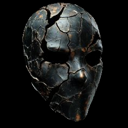

/workspace/TRELLIS.2/assets/12df0aa586740c2035c06a98dd2bd590_mask_cutout.png


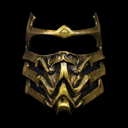

/workspace/TRELLIS.2/assets/1_12c74655-46f7-45cd-8dc6-4f1ab22a7feb_mask_cutout.png


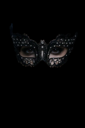

/workspace/TRELLIS.2/assets/2C49B1D2-19DF-487A-B17A-9BA531AFF775_1_105_c_mask_cutout.png


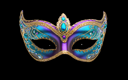

/workspace/TRELLIS.2/assets/360_F_1701818173_PCbBwAO3ojl2VjbDdTjwaBMeSQiv2wiw_mask_cutout.png


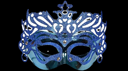

/workspace/TRELLIS.2/assets/71jKoqAQOIL._AC_UY350__mask_cutout.png


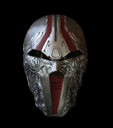

/workspace/TRELLIS.2/assets/96fb77487e261f084514f02d745f834e_mask_cutout.png


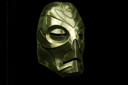

/workspace/TRELLIS.2/assets/Antique brass mask with tarnished details_mask_cutout.png


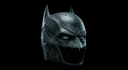

/workspace/TRELLIS.2/assets/Gemini_Generated_Image_6zwof46zwof46zwo_mask_cutout.png


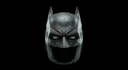

/workspace/TRELLIS.2/assets/Gemini_Generated_Image_fw413dfw413dfw41_mask_cutout.png


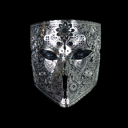

/workspace/TRELLIS.2/assets/MASQUERADE_MASK_FULL_FACE-4__63063_mask_cutout.png


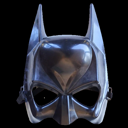

/workspace/TRELLIS.2/assets/SuperheroesFaceMask-Batman_500x_mask_cutout.png


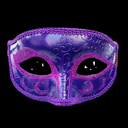

/workspace/TRELLIS.2/assets/VenetianPartyGlitterEyeMask-Assorted_1_1800x1800_mask_cutout.png


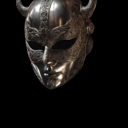

/workspace/TRELLIS.2/assets/creepy-metal-mask_926199-1216324_mask_cutout.png


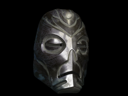

/workspace/TRELLIS.2/assets/dragon-priest-mask-giveaway-with-jonah-lobe-read-body-v0-rpjuagx658rg1_mask_cutout.png


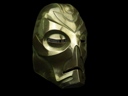

/workspace/TRELLIS.2/assets/dragon-priest-mask-giveaway-with-jonah-lobe-read-body-v0-uwsxv6a958rg1_mask_cutout.png


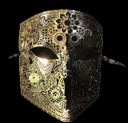

/workspace/TRELLIS.2/assets/gold-and-black-men-s-metal-masquerade-mask-90__01635 copy_mask_cutout.png


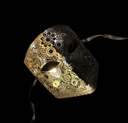

/workspace/TRELLIS.2/assets/gold-and-black-men-s-metal-masquerade-mask-90__01635_mask_cutout.png


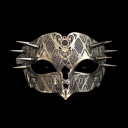

/workspace/TRELLIS.2/assets/il_570xN.6874485104_tkps_mask_cutout.png


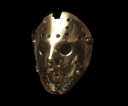

/workspace/TRELLIS.2/assets/il_fullxfull.5802183938_ez95_mask_cutout.png


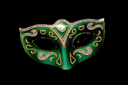

/workspace/TRELLIS.2/assets/images (1)_mask_cutout.png


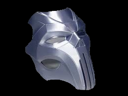

/workspace/TRELLIS.2/assets/images_mask_cutout.png


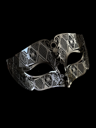

/workspace/TRELLIS.2/assets/intricate-Black-masquerade-mask-detail_mask_cutout.png


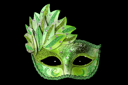

/workspace/TRELLIS.2/assets/istockphoto-532400336-612x612_mask_cutout.png


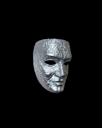

/workspace/TRELLIS.2/assets/king-baldwin-iv-kingdom-of-heaven-the-leper-embroidered-ancient-mask-1920933_mask_cutout.png


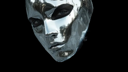

/workspace/TRELLIS.2/assets/man-wearing-metal-face-mask-silver-jacket-capturing-futuristic-fashion-mysterious-vibes-striking-man-wearing-355398487_mask_cutout.png


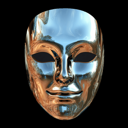

/workspace/TRELLIS.2/assets/pngtree-metallic-reflective-mask-with-realistic-human-face-features-png-image_15171748_mask_cutout.png


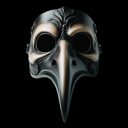

/workspace/TRELLIS.2/assets/psd-plague-doctor-mask-transparent-background-with-editable-mask-layer_1026556-28835_mask_cutout.png


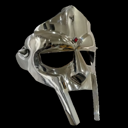

/workspace/TRELLIS.2/assets/s-l400_mask_cutout.png


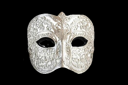

/workspace/TRELLIS.2/assets/silver-venetian-mask-photo_mask_cutout.png


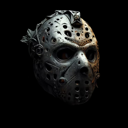

/workspace/TRELLIS.2/assets/there-is-mask-with-face-made-metal-leaf-generative-ai_1034548-68693_mask_cutout.png


In [22]:
import glob
from IPython.display import display

# Use a handful of the bundled example images
all_examples = sorted(glob.glob('assets/example_image/*.webp'))[:4]
all_examples += ['assets/example_image/T.png']  # also include the PNG

# May I? Lol
all_examples = []
all_examples = sorted(glob.glob('/workspace/TRELLIS.2/assets/*cutout*'))

print("Images to process:")
for p in all_examples:
    img = Image.open(p).convert('RGB')
    img.thumbnail((128, 128))
    display(img)
    print(p)

## 9. Run Inference

Default pipeline type is `'1024_cascade'` (best quality).  
Use `'512'` for a quick test (~30 s vs ~3 min on A100).

In [ ]:
import time

PIPELINE_TYPE = '1024_cascade'  # '512' for fast test
OUTPUT_DIR = '/workspace/trellis2_outputs'
os.makedirs(OUTPUT_DIR, exist_ok=True)

for img_path in all_examples:
    name = os.path.splitext(os.path.basename(img_path))[0]
    print(f"\n{'='*60}")
    print(f"Processing: {img_path}")

    image = Image.open(img_path)

    t0 = time.time()
    mesh = pipeline.run(image, pipeline_type=PIPELINE_TYPE)[0]
    mesh.simplify(16_777_216)  # nvdiffrast vertex limit
    print(f"Inference: {time.time()-t0:.1f}s | "
          f"vertices={mesh.vertices.shape[0]:,} faces={mesh.faces.shape[0]:,}")

    # --- Render turntable video ---
    t1 = time.time()
    frames = render_utils.make_pbr_vis_frames(
        render_utils.render_video(mesh, envmap=envmap)
    )
    video_path = os.path.join(OUTPUT_DIR, f'{name}.mp4')
    imageio.mimsave(video_path, frames, fps=15)
    print(f"Video saved: {video_path}  ({time.time()-t1:.1f}s)")

    # --- Export GLB ---
    t2 = time.time()
    glb = o_voxel.postprocess.to_glb(
        vertices          = mesh.vertices,
        faces             = mesh.faces,
        attr_volume       = mesh.attrs,
        coords            = mesh.coords,
        attr_layout       = mesh.layout,
        voxel_size        = mesh.voxel_size,
        aabb              = [[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
        decimation_target = 1_000_000,
        texture_size      = 4096,
        remesh            = True,
        remesh_band       = 1,
        remesh_project    = 0,
        use_tqdm          = True,
    )
    glb_path = os.path.join(OUTPUT_DIR, f'{name}.glb')
    glb.export(glb_path, extension_webp=True)
    print(f"GLB saved:   {glb_path}  ({time.time()-t2:.1f}s)")

    # --- Export USDZ ---
    # t3 = time.time()
    # usdz_path = os.path.join(OUTPUT_DIR, f'{name}.usdz')
    # o_voxel.postprocess.to_usdz(
    #     vertices          = mesh.vertices,
    #     faces             = mesh.faces,
    #     attr_volume       = mesh.attrs,
    #     coords            = mesh.coords,
    #     attr_layout       = mesh.layout,
    #     voxel_size        = mesh.voxel_size,
    #     aabb              = [[-0.5, -0.5, -0.5], [0.5, 0.5, 0.5]],
    #     decimation_target = 1_000_000,
    #     texture_size      = 4096,
    #     remesh            = True,
    #     remesh_band       = 1,
    #     remesh_project    = 0,
    #     file_path         = usdz_path,
    #     use_tqdm          = True,
    # )
    # print(f"USDZ saved:  {usdz_path}  ({time.time()-t3:.1f}s)")

    torch.cuda.empty_cache()

print("\nAll done.")



Processing: /workspace/TRELLIS.2/assets/12df0aa586740c2035c06a98dd2bd590_mask_cutout.png


Sampling texture SLat: 100%|██████████| 12/12 [00:06<00:00,  1.95it/s]


Inference: 124.3s | vertices=3,025,660 faces=6,147,434


Rendering:   0%|          | 0/120 [00:00<?, ?it/s]/usr/local/lib/python3.11/dist-packages/utils3d/torch/nerf.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
/usr/local/lib/python3.11/dist-packages/torch/nn/functional.py:5015: UserWarning: Default grid_sample and affine_grid behavior has changed to align_corners=False since 1.3.0. Please specify align_corners=True if the old behavior is desired. See the documentation of grid_sample for details.
  warnings.warn(
Rendering:   1%|          | 1/120 [00:04<09:30,  4.79s/it]/usr/local/lib/python3.11/dist-packages/utils3d/torch/nerf.py:41: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=False):
Rendering: 100%|██████████| 120/120 [01:13<00:00,  1.63it/s]


Video saved: /workspace/trellis2_outputs/12df0aa586740c2035c06a98dd2bd590_mask_cutout.mp4  (88.7s)


...

Sampling texture SLat: 100%|██████████| 12/12 [00:08<00:00,  1.46it/s]


Inference: 53.3s | vertices=2,825,713 faces=5,668,916


Rendering: 100%|██████████| 120/120 [01:04<00:00,  1.87it/s]


Video saved: /workspace/trellis2_outputs/71jKoqAQOIL._AC_UY350__mask_cutout.mp4  (79.4s)


Finalizing mesh: 100%|██████████| 6/6 [03:21<00:00, 33.51s/it]        


## 10. Preview Outputs

In [18]:
# List generated files
!ls -lh {OUTPUT_DIR}

total 0


In [19]:
# Preview the first video inline
from IPython.display import Video
import glob

videos = sorted(glob.glob(f'{OUTPUT_DIR}/*.mp4'))
if videos:
    display(Video(videos[0], embed=True, width=512))

## 11. Download Outputs

Zip everything up for easy download from the RunPod file manager.

In [20]:
!zip -r /workspace/trellis2_outputs.zip {OUTPUT_DIR}
print("Ready: /workspace/trellis2_outputs.zip")

/bin/bash: line 1: zip: command not found
Ready: /workspace/trellis2_outputs.zip


---
## Optional: Single-Image Quick Test

Drop your own image at `/workspace/my_image.png` and run this cell.

In [21]:
MY_IMAGE = '/workspace/my_image.png'  # <-- change this

if os.path.exists(MY_IMAGE):
    image = Image.open(MY_IMAGE)
    mesh = pipeline.run(image, pipeline_type='512')[0]  # '512' for speed
    mesh.simplify(16_777_216)

    glb = o_voxel.postprocess.to_glb(
        vertices=mesh.vertices, faces=mesh.faces,
        attr_volume=mesh.attrs, coords=mesh.coords,
        attr_layout=mesh.layout, voxel_size=mesh.voxel_size,
        aabb=[[-0.5,-0.5,-0.5],[0.5,0.5,0.5]],
        decimation_target=500_000, texture_size=2048,
        remesh=True, remesh_band=1, remesh_project=0,
    )
    out = '/workspace/my_output.glb'
    glb.export(out, extension_webp=True)
    print(f"Saved: {out}")

    o_voxel.postprocess.to_usdz(
        vertices=mesh.vertices, faces=mesh.faces,
        attr_volume=mesh.attrs, coords=mesh.coords,
        attr_layout=mesh.layout, voxel_size=mesh.voxel_size,
        aabb=[[-0.5,-0.5,-0.5],[0.5,0.5,0.5]],
        decimation_target=500_000, texture_size=2048,
        remesh=True, remesh_band=1, remesh_project=0,
        file_path='/workspace/my_output.usdz',
    )
    print("Saved: /workspace/my_output.usdz")

    torch.cuda.empty_cache()
else:
    print(f"File not found: {MY_IMAGE}")


File not found: /workspace/my_image.png
